# Experiment: Figure 3 RT Distribution And Example Trajectories

This notebook reads a merged DDM+circuit run bundle at `results/figure3/fig3_psychometric_c0p5_n1000_dur4000/`.

It can load either the raw per-model bundles (`ddm/`, `circuit/`) or the merged-only top-level Figure 3 bundle. The middle panel reconstructs the selected DDM example trajectories directly from the saved condition seed and then replays the circuit locally so the plotted trajectories stay tied to the saved examples.


In [6]:
from __future__ import annotations

import json
import runpy
from pathlib import Path


_NOTEBOOK_SETUP = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    helper = candidate / "figures_code" / "notebook_setup.py"
    if helper.exists():
        _NOTEBOOK_SETUP = runpy.run_path(str(helper))
        break
if _NOTEBOOK_SETUP is None:
    raise RuntimeError("Could not locate figures_code/notebook_setup.py")

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import numpy as np

from CANN_DDM_model_rate_based import CANN_DDM_model
from rate_model_core.accumulator_simulation import (
    _build_circuit_baseline_params,
    prepare_circuit_target_diffusion_calibration,
)
%config InlineBackend.figure_format = 'retina'

REPO_ROOT = _NOTEBOOK_SETUP["REPO_ROOT"]
REPO_ROOT


PosixPath('/projectnb/ecog-eeg/cyw6/CANN_DDM_rate_model')

## Dataset Path And Plotting Defaults

Only this cell should need updating if the Figure 3 run folder changes. This notebook now supports both Figure 3 layouts:
- raw model sub-bundles under `results/figure3/<run_name>/ddm/` and `.../circuit/`
- merged-only runs where only the top-level `dataset.npz` / `config.json` remain

If both are present, the notebook prefers the raw model bundle. If only the merged bundle exists, it extracts the per-model views automatically.


In [7]:
RUN_ROOT = REPO_ROOT / "results" / "figure3" / "fig3_psychometric_c0p5_n10000_dur4000"
COMBINED_DATASET_PATH = RUN_ROOT / "dataset.npz"
COMBINED_CONFIG_PATH = RUN_ROOT / "config.json"
DDM_RUN_ROOT = RUN_ROOT / "ddm"
DDM_DATASET_PATH = DDM_RUN_ROOT / "dataset.npz"
DDM_CONFIG_PATH = DDM_RUN_ROOT / "config.json"
CIRCUIT_RUN_ROOT = RUN_ROOT / "circuit"
CIRCUIT_DATASET_PATH = CIRCUIT_RUN_ROOT / "dataset.npz"
CIRCUIT_CONFIG_PATH = CIRCUIT_RUN_ROOT / "config.json"
TARGET_DRIFT_RATE = 0.25
TARGET_NOISE_SCALE = 0.5
TRACE_DT_MS = 1.0
RT_DENSITY_N_TERMS = 600
THEORY_GRID_SIZE = 1200
THEORY_LINEWIDTH = 2.0

RUN_ROOT


PosixPath('/projectnb/ecog-eeg/cyw6/CANN_DDM_rate_model/results/figure3/fig3_psychometric_c0p5_n10000_dur4000')

## Helper Functions

The helpers keep the notebook deterministic:
- load the saved DDM bundle and optionally the saved circuit bundle
- choose one example correct trial and one example incorrect trial from the target condition
- reconstruct the DDM example trajectories directly from the saved condition seed instead of reading stored `x_traj`
- fall back cleanly to the DDM bundle if the saved circuit bundle is absent
- replay the circuit locally for the selected DDM examples
- plot the RT histograms and the paired DDM/circuit trajectories


In [8]:
def load_fig3_dataset(dataset_path: Path, config_path: Path) -> dict:
    dataset_path = Path(dataset_path)
    config_path = Path(config_path)
    if not dataset_path.exists():
        raise FileNotFoundError(f"Dataset not found: {dataset_path}")
    if not config_path.exists():
        raise FileNotFoundError(f"Config not found: {config_path}")

    with np.load(dataset_path, allow_pickle=True) as data:
        metadata = json.loads(str(data["metadata_json"].item()))
        config = json.loads(config_path.read_text())
        coherence_values = np.asarray(data["coherence_values"], dtype=float)
        drift_gain = float(config.get("drift_gain", 1.0))

        condition_labels = metadata.get("condition_labels")
        if condition_labels is None:
            condition_labels = [f"coh_{coh:+.3g}" for coh in coherence_values]

        drift_rates = metadata.get("condition_drift_rates")
        if drift_rates is None:
            drift_rates = drift_gain * coherence_values

        noise_scales = metadata.get("condition_noise_scales")
        if noise_scales is None:
            noise_scales = np.full(coherence_values.shape, float(config["noise_scale"]), dtype=float)

        num_trials_per_condition = metadata.get("condition_num_trials")
        if num_trials_per_condition is None:
            num_trials_per_condition = np.full(coherence_values.shape, int(config["num_trials"]), dtype=int)

        return {
            "dataset_path": dataset_path,
            "config_path": config_path,
            "config": config,
            "metadata": metadata,
            "coherence_values": coherence_values,
            "condition_labels": list(condition_labels),
            "condition_seeds": [int(seed) for seed in metadata.get("condition_seeds", [])],
            "drift_rates": np.asarray(drift_rates, dtype=float),
            "noise_scales": np.asarray(noise_scales, dtype=float),
            "num_trials_per_condition": np.asarray(num_trials_per_condition, dtype=int),
            "t_start_ms": int(config["t_start"]),
            "dt_ddm_ms": float(config["dt_ddm"]),
            "dur_ms": int(config["dur"]),
            "max_time_ms": int(config["max_time"]),
            "x0": float(config["x0"]),
            "boundary": float(config["boundary"]),
            "choice": np.asarray(data["choice"]),
            "hit_boundary": np.asarray(data["hit_boundary"], dtype=bool),
            "rt_ms": np.asarray(data["rt_ms"], dtype=float),
            "final_x": np.asarray(data["final_x"], dtype=float),
            "time_ms": np.asarray(data["time_ms"], dtype=float),
            "has_saved_x_traj": bool("x_traj" in data.files),
        }


def maybe_load_fig3_dataset(dataset_path: Path, config_path: Path) -> dict | None:
    dataset_path = Path(dataset_path)
    config_path = Path(config_path)
    if not dataset_path.exists() or not config_path.exists():
        return None
    return load_fig3_dataset(dataset_path, config_path)


def discover_condition_batch_layout(run_root: Path, condition_labels: list[str], model_name: str) -> tuple[list[list[int]], list[list[int]]]:
    batch_seeds_by_condition = []
    batch_num_trials_by_condition = []
    for condition_label in condition_labels:
        condition_dir = Path(run_root) / "conditions" / str(condition_label)
        batch_dirs = sorted(
            path for path in condition_dir.glob("batch_*")
            if path.is_dir() and (path / f"{model_name}_dataset.npz").exists()
        )
        batch_seeds = []
        batch_counts = []
        for batch_dir in batch_dirs:
            dataset_path = batch_dir / f"{model_name}_dataset.npz"
            with np.load(dataset_path, allow_pickle=True) as batch_data:
                batch_metadata = json.loads(str(batch_data["metadata_json"].item()))
                batch_seeds.append(int(batch_metadata["condition_seeds"][0]))
                batch_counts.append(int(np.asarray(batch_data["choice"]).shape[1]))
        batch_seeds_by_condition.append(batch_seeds)
        batch_num_trials_by_condition.append(batch_counts)
    return batch_seeds_by_condition, batch_num_trials_by_condition


def load_fig3_model_from_combined(run_root: Path, model_name: str) -> dict | None:
    dataset_path = Path(run_root) / "dataset.npz"
    config_path = Path(run_root) / "config.json"
    if not dataset_path.exists() or not config_path.exists():
        return None

    with np.load(dataset_path, allow_pickle=True) as data:
        metadata = json.loads(str(data["metadata_json"].item()))
        top_level_config = json.loads(config_path.read_text())
        model_names = [str(name) for name in np.asarray(data["model_names"]).tolist()]
        if model_name not in model_names:
            raise ValueError(f"Model '{model_name}' not found in combined dataset {dataset_path}")
        model_index = model_names.index(model_name)
        model_config = metadata.get(f"{model_name}_config")
        model_metadata = metadata[f"{model_name}_metadata"]
        if model_config is None:
            model_config = {
                "model": model_name,
                "decision_mode": top_level_config.get("decision_mode", "continuous"),
                "decision_paradigm": top_level_config.get("decision_paradigm", "free_response"),
                "drift_gain": top_level_config.get("drift_gain", 1.0),
                "noise_scale": top_level_config["noise_scale"],
                "dt_ddm": top_level_config["dt_ddm"],
                "dt_model": top_level_config["dt_model"],
                "t_start": top_level_config["t_start"],
                "dur": top_level_config["dur"],
                "max_time": top_level_config.get("max_time", top_level_config["dur"]),
                "x0": top_level_config["x0"],
                "boundary": top_level_config["boundary"],
                "num_trials": top_level_config["num_trials"],
                "seed": top_level_config.get("seed"),
            }
        coherence_values = np.asarray(data["coherence_values"], dtype=float)
        drift_gain = float(model_config.get("drift_gain", 1.0))

        condition_labels = model_metadata.get("condition_labels")
        if condition_labels is None:
            condition_labels = [f"coh_{coh:+.3g}" for coh in coherence_values]

        drift_rates = model_metadata.get("condition_drift_rates")
        if drift_rates is None:
            drift_rates = drift_gain * coherence_values

        noise_scales = model_metadata.get("condition_noise_scales")
        if noise_scales is None:
            noise_scales = np.full(coherence_values.shape, float(model_config["noise_scale"]), dtype=float)

        num_trials_per_condition = model_metadata.get("condition_num_trials")
        if num_trials_per_condition is None:
            num_trials_per_condition = np.full(coherence_values.shape, int(model_config["num_trials"]), dtype=int)

        time_ms = np.asarray(data["time_ms"], dtype=float)
        if time_ms.ndim == 2:
            time_ms = np.asarray(time_ms[model_index], dtype=float)

        has_saved_x_traj = bool("x_traj" in data.files)
        x_traj = None
        if has_saved_x_traj:
            x_traj = np.asarray(data["x_traj"][model_index])
        batch_seeds_by_condition, batch_num_trials_by_condition = discover_condition_batch_layout(
            run_root,
            list(condition_labels),
            str(model_name),
        )

        return {
            "dataset_path": dataset_path,
            "config_path": config_path,
            "config": model_config,
            "metadata": model_metadata,
            "coherence_values": coherence_values,
            "condition_labels": list(condition_labels),
            "condition_seeds": [int(seed) for seed in model_metadata.get("condition_seeds", [])],
            "batch_seeds_by_condition": batch_seeds_by_condition,
            "batch_num_trials_by_condition": batch_num_trials_by_condition,
            "drift_rates": np.asarray(drift_rates, dtype=float),
            "noise_scales": np.asarray(noise_scales, dtype=float),
            "num_trials_per_condition": np.asarray(num_trials_per_condition, dtype=int),
            "t_start_ms": int(model_config["t_start"]),
            "dt_ddm_ms": float(model_config["dt_ddm"]),
            "dur_ms": int(model_config["dur"]),
            "max_time_ms": int(model_config["max_time"]),
            "x0": float(model_config["x0"]),
            "boundary": float(model_config["boundary"]),
            "choice": np.asarray(data["choice"][model_index]),
            "hit_boundary": np.asarray(data["hit_boundary"][model_index], dtype=bool),
            "rt_ms": np.asarray(data["rt_ms"][model_index], dtype=float),
            "final_x": np.asarray(data["final_x"][model_index], dtype=float),
            "time_ms": time_ms,
            "has_saved_x_traj": has_saved_x_traj,
            "x_traj": x_traj,
        }


def load_fig3_model_bundle(run_root: Path, model_name: str) -> dict:
    run_root = Path(run_root)
    raw_root = run_root / model_name
    raw_dataset = raw_root / "dataset.npz"
    raw_config = raw_root / "config.json"
    if raw_dataset.exists() and raw_config.exists():
        return load_fig3_dataset(raw_dataset, raw_config)
    combined = load_fig3_model_from_combined(run_root, model_name)
    if combined is None:
        raise FileNotFoundError(f"Could not find raw or combined Figure 3 bundle for model '{model_name}' under {run_root}")
    return combined


def maybe_load_fig3_model_bundle(run_root: Path, model_name: str) -> dict | None:
    run_root = Path(run_root)
    raw_root = run_root / model_name
    raw_dataset = raw_root / "dataset.npz"
    raw_config = raw_root / "config.json"
    if raw_dataset.exists() and raw_config.exists():
        return load_fig3_dataset(raw_dataset, raw_config)
    return load_fig3_model_from_combined(run_root, model_name)


def finite_rt_mask(rt_ms: np.ndarray) -> np.ndarray:
    rt_ms = np.asarray(rt_ms, dtype=float)
    return np.isfinite(rt_ms) & (rt_ms > 0.0)


def correct_choice_value(drift_rate: float) -> int:
    return 1 if float(drift_rate) >= 0.0 else -1


def condition_descriptor(raw: dict, condition_index: int) -> str:
    v = float(raw["drift_rates"][condition_index])
    c = float(raw["noise_scales"][condition_index])
    return rf"$v={v:.2f}, c={c:.2f}$"


def find_condition_index(raw: dict, *, drift_rate: float, noise_scale: float) -> int:
    drift_rates = np.asarray(raw["drift_rates"], dtype=float)
    noise_scales = np.asarray(raw["noise_scales"], dtype=float)
    match = np.flatnonzero(
        np.isclose(drift_rates, float(drift_rate)) & np.isclose(noise_scales, float(noise_scale))
    )
    if match.size == 1:
        return int(match[0])
    if match.size == 0 and drift_rates.size == 1:
        print(
            f"Requested condition (v={float(drift_rate):.3g}, c={float(noise_scale):.3g}) not found; "
            f"using the only available condition (v={float(drift_rates[0]):.3g}, c={float(noise_scales[0]):.3g})."
        )
        return 0
    raise ValueError(
        f"Expected exactly one condition for drift_rate={drift_rate} and noise_scale={noise_scale}, found {match.size}"
    )


def choose_response_trial(raw: dict, condition_index: int, response_choice: int, quantile: float = 0.5) -> int:
    choice = raw["choice"][condition_index]
    rt_ms = raw["rt_ms"][condition_index]
    response_indices = np.flatnonzero((choice == int(response_choice)) & finite_rt_mask(rt_ms))
    if response_indices.size == 0:
        raise ValueError(
            f"No trials available for response_choice={response_choice} at condition index {condition_index}"
        )
    ordered = response_indices[np.argsort(rt_ms[response_indices], kind="stable")]
    quantile = float(np.clip(float(quantile), 0.0, 1.0))
    selected_rank = int(round(quantile * (len(ordered) - 1)))
    return int(ordered[selected_rank])


def get_hit_index(hit_trace: np.ndarray) -> int | None:
    hit_indices = np.flatnonzero(np.asarray(hit_trace, dtype=bool))
    if hit_indices.size == 0:
        return None
    return int(hit_indices[0])


def reconstruct_example_ddm_trial(raw: dict, condition_index: int, trial_index: int) -> dict:
    drift_rate = float(raw["drift_rates"][condition_index])
    noise_scale = float(raw["noise_scales"][condition_index])
    condition_seed = int(raw["condition_seeds"][condition_index])
    num_trials = int(raw["num_trials_per_condition"][condition_index])
    batch_seeds = list(raw.get("batch_seeds_by_condition", [])[condition_index]) if raw.get("batch_seeds_by_condition") else []
    batch_trial_counts = list(raw.get("batch_num_trials_by_condition", [])[condition_index]) if raw.get("batch_num_trials_by_condition") else []
    dt_ddm_ms = int(round(float(raw["dt_ddm_ms"])))
    dt_s = float(raw["dt_ddm_ms"]) * 1e-3
    t_start_ms = int(raw["t_start_ms"])
    dur_ms = int(raw["dur_ms"])
    max_time_ms = int(raw["max_time_ms"])
    x0 = float(raw["x0"])
    boundary = float(raw["boundary"])
    mar = float(raw["config"].get("mar", 0.0))
    c_eb = raw["config"].get("c_eb")

    replay_seed = condition_seed
    replay_num_trials = num_trials
    local_trial_index = int(trial_index)
    batch_index = None
    if batch_seeds and batch_trial_counts:
        start = 0
        for candidate_batch_index, batch_count in enumerate(batch_trial_counts):
            stop = start + int(batch_count)
            if int(trial_index) < stop:
                batch_index = int(candidate_batch_index)
                replay_seed = int(batch_seeds[candidate_batch_index])
                replay_num_trials = int(batch_count)
                local_trial_index = int(trial_index) - start
                break
            start = stop


    step_starts = np.arange(0, max_time_ms, dt_ddm_ms, dtype=int)
    rng = np.random.default_rng(replay_seed)
    x_curr = np.full(replay_num_trials, x0, dtype=float)
    hit_boundary = np.zeros(replay_num_trials, dtype=bool)
    choice = np.zeros(replay_num_trials, dtype=np.int8)
    rt_ms = np.full(replay_num_trials, np.nan, dtype=float)
    step_normals = np.zeros(step_starts.size, dtype=float)
    dW_all = np.zeros(max_time_ms, dtype=float)
    trial_trace = np.empty(max_time_ms, dtype=float)
    trial_active = True
    trial_hit_choice = 0
    trial_rt_ms = float('nan')

    for step_index, start in enumerate(step_starts):
        stop = min(start + dt_ddm_ms, max_time_ms)
        if start < t_start_ms:
            trial_trace[start:stop] = x_curr[local_trial_index]
            continue

        drift_increment = drift_rate * dt_s if start < dur_ms else 0.0
        normals = rng.standard_normal(replay_num_trials)
        step_normals[step_index] = float(normals[local_trial_index])
        dW_all[start] = np.sqrt(dt_s) * step_normals[step_index]
        increments = drift_increment + noise_scale * dW_all[start] * np.ones(replay_num_trials, dtype=float)

        if np.any(~hit_boundary):
            active_trials = ~hit_boundary
            x_curr[active_trials] += increments[active_trials]
            right_hits = active_trials & (x_curr >= boundary)
            left_hits = active_trials & (x_curr <= 0.0)
            newly_hit = right_hits | left_hits

            x_curr[right_hits] = boundary
            x_curr[left_hits] = 0.0
            choice[right_hits] = 1
            choice[left_hits] = -1
            hit_boundary[newly_hit] = True
            rt_ms[newly_hit] = float(start - t_start_ms)

        if trial_active:
            trial_value = float(x_curr[local_trial_index])
            if hit_boundary[local_trial_index]:
                trial_active = False
                trial_hit_choice = int(choice[local_trial_index])
                trial_rt_ms = float(rt_ms[local_trial_index])
                trial_value = boundary if trial_hit_choice == 1 else 0.0
            trial_trace[start:stop] = trial_value
        else:
            trial_trace[start:stop] = boundary if trial_hit_choice == 1 else 0.0

    return {
        "condition_index": int(condition_index),
        "trial_index": int(trial_index),
        "condition_label": raw["condition_labels"][condition_index],
        "condition_seed": condition_seed,
        "replay_seed": int(replay_seed),
        "replay_num_trials": int(replay_num_trials),
        "local_trial_index": int(local_trial_index),
        "batch_index": batch_index,
        "drift_rate": drift_rate,
        "noise_scale": noise_scale,
        "num_trials": num_trials,
        "dt_ddm_ms": dt_ddm_ms,
        "dt_s": dt_s,
        "t_start_ms": t_start_ms,
        "dur_ms": dur_ms,
        "max_time_ms": max_time_ms,
        "x0": x0,
        "boundary": boundary,
        "mar": mar,
        "c_eb": c_eb,
        "time_ms": np.asarray(raw["time_ms"], dtype=float),
        "ddm_x": trial_trace,
        "rt_ms": float(raw["rt_ms"][condition_index, trial_index]),
        "choice": int(raw["choice"][condition_index, trial_index]),
        "replayed_rt_ms": trial_rt_ms,
        "replayed_choice": int(choice[local_trial_index]),
        "step_starts_ms": step_starts,
        "step_normals": step_normals,
        "dW_all": dW_all,
    }


def derive_circuit_trial_seed(replay_seed: int, replay_num_trials: int, local_trial_index: int) -> int:
    child_sequences = np.random.SeedSequence(int(replay_seed)).spawn(int(replay_num_trials))
    return int(child_sequences[int(local_trial_index)].generate_state(1)[0])


def prepare_shared_circuit_calibration(raw: dict) -> dict:
    return prepare_circuit_target_diffusion_calibration(
        dt_ddm=float(raw["dt_ddm_ms"]),
        t_start=int(raw["t_start_ms"]),
        dur=int(raw["dur_ms"]),
        max_time=int(raw["max_time_ms"]),
        seed=int(raw["config"]["seed"]),
        mar=float(raw["config"].get("mar", 0.0)),
        c_eb=raw["config"].get("c_eb"),
    )


def build_circuit_replay_from_example(example_trial: dict, calibration: dict) -> dict:
    trial_seed = derive_circuit_trial_seed(
        example_trial["replay_seed"],
        example_trial["replay_num_trials"],
        example_trial["local_trial_index"],
    )
    params = _build_circuit_baseline_params(
        coherence=1.0,
        drift_gain=float(example_trial["drift_rate"]),
        noise_scale=float(example_trial["noise_scale"]),
        dt_ddm=float(example_trial["dt_ddm_ms"]),
        t_start=int(example_trial["t_start_ms"]),
        dur=int(example_trial["dur_ms"]),
        max_time=int(example_trial["max_time_ms"]),
        seed=int(trial_seed),
        kappa=float(calibration["kappa"]),
        x0=float(example_trial["x0"]),
        boundary=float(example_trial["boundary"]),
        mar=float(example_trial.get("mar", 0.0)),
        c_eb=example_trial.get("c_eb"),
    )
    model = CANN_DDM_model(CANN_params=params)

    dt_ddm_ms = int(example_trial["dt_ddm_ms"])
    v_drift_steps = np.zeros(example_trial["step_starts_ms"].size, dtype=float)
    v_noise_steps = np.zeros(example_trial["step_starts_ms"].size, dtype=float)
    for step_index, start in enumerate(example_trial["step_starts_ms"]):
        if start < example_trial["t_start_ms"] or start >= example_trial["dur_ms"]:
            continue
        dW = float(example_trial["dW_all"][start])
        v_drift_steps[step_index] = (
            float(example_trial["drift_rate"]) * float(example_trial["dt_s"])
            / (float(model.drive_x_speed_unit) * float(dt_ddm_ms))
        )
        v_noise_steps[step_index] = (
            float(example_trial["noise_scale"]) * dW
            / (float(model.drive_x_speed_unit) * float(dt_ddm_ms))
        )

    model.dW_all = np.asarray(example_trial["dW_all"], dtype=float)
    model.v_drift_all = model.expand_decision_step_values(
        example_trial["max_time_ms"],
        float(example_trial["dt_ddm_ms"]),
        v_drift_steps,
    )
    model.v_noise_all = model.expand_decision_step_values(
        example_trial["max_time_ms"],
        float(example_trial["dt_ddm_ms"]),
        v_noise_steps,
    )
    model.v_drive_all = model.v_drift_all + model.v_noise_all
    model.x_traj = model.get_x_traj_continuous(
        example_trial["t_start_ms"],
        example_trial["dur_ms"],
        example_trial["drift_rate"],
        example_trial["noise_scale"],
        float(example_trial["dt_ddm_ms"]),
        example_trial["x0"],
        model.dW_all,
        example_trial["boundary"],
    )

    runner = model.build_runner(mon_vars=["x_E", "hit_boundary"], progress_bar=False, dt=TRACE_DT_MS)
    runner.run(int(example_trial["max_time_ms"]))

    x_E = np.asarray(runner.mon.x_E).reshape(-1)
    hit_boundary = np.asarray(runner.mon.hit_boundary).reshape(-1).astype(bool)
    first_hit_index = get_hit_index(hit_boundary)
    if first_hit_index is None:
        first_hit_index = len(x_E) - 1

    return {
        "model": model,
        "trial_seed": int(trial_seed),
        "time_ms": np.arange(len(x_E), dtype=float) * float(TRACE_DT_MS),
        "x_E": x_E,
        "hit_boundary": hit_boundary,
        "first_hit_index": int(first_hit_index),
        "first_hit_time_ms": float(first_hit_index * TRACE_DT_MS),
    }


def make_rt_bins(raw: dict, bin_width_ms: float) -> np.ndarray:
    rt_ms = np.asarray(raw["rt_ms"], dtype=float)
    max_rt = float(np.nanmax(rt_ms[finite_rt_mask(rt_ms)]))
    right_edge = bin_width_ms * np.ceil(max_rt / bin_width_ms)
    return np.arange(0.0, right_edge + bin_width_ms, bin_width_ms)


def normalized_density_histogram(sample_rt_ms: np.ndarray, bins_ms: np.ndarray, total_trial_count: int) -> tuple[np.ndarray, np.ndarray]:
    counts, edges = np.histogram(sample_rt_ms, bins=bins_ms)
    widths_ms = np.diff(edges)
    if sample_rt_ms.size == 0 or int(total_trial_count) <= 0:
        return np.zeros_like(widths_ms, dtype=float), edges
    heights = counts.astype(float) / (float(total_trial_count) * widths_ms)
    return heights, edges


def ddm_upper_hit_subdensity(t_s: np.ndarray, drift_rate: float, noise_scale: float, x0: float, boundary: float, n_terms: int) -> np.ndarray:
    t_s = np.asarray(t_s, dtype=float)
    density = np.zeros_like(t_s, dtype=float)
    valid = t_s > 0.0
    if not np.any(valid):
        return density

    sigma = float(noise_scale)
    mu = float(drift_rate)
    z = float(x0)
    a = float(boundary)
    n = np.arange(1, int(n_terms) + 1, dtype=float)[:, None]
    t_valid = t_s[valid][None, :]
    expo = np.exp(-(n ** 2) * (np.pi ** 2) * (sigma ** 2) * t_valid / (2.0 * a ** 2))
    series = np.sum(n * ((-1.0) ** (n + 1.0)) * np.sin(n * np.pi * z / a) * expo, axis=0)
    prefactor = (np.pi * sigma ** 2 / (a ** 2)) * np.exp(mu * (a - z) / (sigma ** 2) - (mu ** 2) * t_s[valid] / (2.0 * sigma ** 2))
    density[valid] = np.maximum(prefactor * series, 0.0)
    return density


def ddm_lower_hit_subdensity(t_s: np.ndarray, drift_rate: float, noise_scale: float, x0: float, boundary: float, n_terms: int) -> np.ndarray:
    t_s = np.asarray(t_s, dtype=float)
    density = np.zeros_like(t_s, dtype=float)
    valid = t_s > 0.0
    if not np.any(valid):
        return density

    sigma = float(noise_scale)
    mu = float(drift_rate)
    z = float(x0)
    a = float(boundary)
    n = np.arange(1, int(n_terms) + 1, dtype=float)[:, None]
    t_valid = t_s[valid][None, :]
    expo = np.exp(-(n ** 2) * (np.pi ** 2) * (sigma ** 2) * t_valid / (2.0 * a ** 2))
    series = np.sum(n * np.sin(n * np.pi * z / a) * expo, axis=0)
    prefactor = (np.pi * sigma ** 2 / (a ** 2)) * np.exp(-mu * z / (sigma ** 2) - (mu ** 2) * t_s[valid] / (2.0 * sigma ** 2))
    density[valid] = np.maximum(prefactor * series, 0.0)
    return density


def ddm_response_probabilities(drift_rate: float, noise_scale: float, x0: float, boundary: float) -> tuple[float, float]:
    mu = float(drift_rate)
    sigma2 = float(noise_scale) ** 2
    z = float(x0)
    a = float(boundary)
    if np.isclose(mu, 0.0):
        p_upper = z / a
    else:
        p_upper = (1.0 - np.exp(-2.0 * mu * z / sigma2)) / (1.0 - np.exp(-2.0 * mu * a / sigma2))
    p_upper = float(np.clip(p_upper, 0.0, 1.0))
    return p_upper, float(1.0 - p_upper)


def build_rt_theory_curves(
    raw: dict,
    condition_index: int,
    x_max_ms: float,
    *,
    window_ms: float | None = None,
) -> dict[str, np.ndarray | float]:
    x_max_ms = float(x_max_ms)
    if window_ms is None:
        window_ms = float(raw["max_time_ms"])
    window_ms = float(window_ms)
    eval_max_ms = min(x_max_ms, window_ms)
    t_ms = np.linspace(0.0, eval_max_ms, int(THEORY_GRID_SIZE))
    t_s = t_ms * 1e-3
    upper = ddm_upper_hit_subdensity(
        t_s,
        drift_rate=float(raw["drift_rates"][condition_index]),
        noise_scale=float(raw["noise_scales"][condition_index]),
        x0=float(raw["x0"]),
        boundary=float(raw["boundary"]),
        n_terms=int(RT_DENSITY_N_TERMS),
    )
    lower = ddm_lower_hit_subdensity(
        t_s,
        drift_rate=float(raw["drift_rates"][condition_index]),
        noise_scale=float(raw["noise_scales"][condition_index]),
        x0=float(raw["x0"]),
        boundary=float(raw["boundary"]),
        n_terms=int(RT_DENSITY_N_TERMS),
    )

    window_grid_ms = np.linspace(0.0, window_ms, int(THEORY_GRID_SIZE))
    window_grid_s = window_grid_ms * 1e-3
    upper_window = ddm_upper_hit_subdensity(
        window_grid_s,
        drift_rate=float(raw["drift_rates"][condition_index]),
        noise_scale=float(raw["noise_scales"][condition_index]),
        x0=float(raw["x0"]),
        boundary=float(raw["boundary"]),
        n_terms=int(RT_DENSITY_N_TERMS),
    )
    lower_window = ddm_lower_hit_subdensity(
        window_grid_s,
        drift_rate=float(raw["drift_rates"][condition_index]),
        noise_scale=float(raw["noise_scales"][condition_index]),
        x0=float(raw["x0"]),
        boundary=float(raw["boundary"]),
        n_terms=int(RT_DENSITY_N_TERMS),
    )
    p_upper, p_lower = ddm_response_probabilities(
        drift_rate=float(raw["drift_rates"][condition_index]),
        noise_scale=float(raw["noise_scales"][condition_index]),
        x0=float(raw["x0"]),
        boundary=float(raw["boundary"]),
    )
    p_upper_window = float(np.trapz(upper_window, window_grid_s))
    p_lower_window = float(np.trapz(lower_window, window_grid_s))
    p_miss_window = float(max(0.0, 1.0 - p_upper_window - p_lower_window))
    return {
        "t_ms": t_ms,
        "upper": upper * 1e-3,
        "lower": lower * 1e-3,
        "p_upper": p_upper,
        "p_lower": p_lower,
        "p_upper_window": p_upper_window,
        "p_lower_window": p_lower_window,
        "p_miss_window": p_miss_window,
        "window_ms": window_ms,
    }


def summarize_conditions(raw: dict, condition_indices: list[int] | tuple[int, ...] | None = None) -> list[dict[str, float | int | str]]:
    rows = []
    if condition_indices is None:
        condition_indices = tuple(range(len(raw["condition_labels"])))
    for condition_index in condition_indices:
        choice = raw["choice"][condition_index]
        rt_ms = raw["rt_ms"][condition_index]
        total_trial_count = int(choice.size)
        correct_choice = correct_choice_value(raw["drift_rates"][condition_index])
        incorrect_choice = -correct_choice
        correct_rt = rt_ms[(choice == correct_choice) & finite_rt_mask(rt_ms)]
        error_rt = rt_ms[(choice == incorrect_choice) & finite_rt_mask(rt_ms)]
        rows.append(
            {
                "condition": condition_descriptor(raw, condition_index),
                "n_correct": int(correct_rt.size),
                "n_error": int(error_rt.size),
                "empirical_p_correct": float(correct_rt.size / total_trial_count),
                "empirical_p_error": float(error_rt.size / total_trial_count),
                "mean_correct_rt_ms": float(np.mean(correct_rt)) if correct_rt.size else float("nan"),
                "mean_error_rt_ms": float(np.mean(error_rt)) if error_rt.size else float("nan"),
            }
        )
    return rows


def plot_fig3_circuit_rt_traj(
    ddm_raw: dict,
    ddm_condition_index: int,
    rt_raw: dict,
    rt_condition_index: int,
    example_trials: dict[str, dict],
    circuit_replays: dict[str, dict],
) -> tuple[plt.Figure, tuple[plt.Axes, plt.Axes, plt.Axes]]:
    bins = make_rt_bins(rt_raw, BIN_WIDTH_MS)
    fig = plt.figure(figsize=FIGSIZE)
    grid = fig.add_gridspec(3, 1, height_ratios=GRID_HEIGHT_RATIOS, hspace=0.0)
    ax_top = fig.add_subplot(grid[0])
    ax_mid = fig.add_subplot(grid[1], sharex=ax_top)
    ax_bottom = fig.add_subplot(grid[2], sharex=ax_top)

    choice = rt_raw["choice"][rt_condition_index]
    rt_ms = rt_raw["rt_ms"][rt_condition_index]
    total_trial_count = int(choice.size)
    correct_choice = correct_choice_value(rt_raw["drift_rates"][rt_condition_index])
    incorrect_choice = -correct_choice
    correct_rt = rt_ms[(choice == correct_choice) & finite_rt_mask(rt_ms)]
    error_rt = rt_ms[(choice == incorrect_choice) & finite_rt_mask(rt_ms)]
    correct_heights, correct_edges = normalized_density_histogram(correct_rt, bins, total_trial_count)
    error_heights, error_edges = normalized_density_histogram(error_rt, bins, total_trial_count)
    x_max = float(bins[-1])
    theory = build_rt_theory_curves(ddm_raw, ddm_condition_index, x_max)
    common_density_max = max(
        float(np.max(correct_heights)) if correct_heights.size else 0.0,
        float(np.max(error_heights)) if error_heights.size else 0.0,
        float(np.max(theory["upper"])) if np.size(theory["upper"]) else 0.0,
        float(np.max(theory["lower"])) if np.size(theory["lower"]) else 0.0,
    )

    ax_top.bar(
        correct_edges[:-1],
        correct_heights,
        width=np.diff(correct_edges),
        align="edge",
        color=CORRECT_COLOR,
        alpha=HIST_ALPHA,
        edgecolor="none",
        zorder=1,
    )
    ax_top.stairs(
        correct_heights,
        correct_edges,
        color=CORRECT_COLOR,
        alpha=1.0,
        linewidth=PROFILE_LINEWIDTH,
        linestyle="-",
        zorder=5,
    )
    ax_bottom.bar(
        error_edges[:-1],
        -error_heights,
        width=np.diff(error_edges),
        align="edge",
        color=ERROR_COLOR,
        alpha=HIST_ALPHA,
        edgecolor="none",
        zorder=1,
    )
    ax_bottom.stairs(
        -error_heights,
        error_edges,
        color=ERROR_COLOR,
        alpha=1.0,
        linewidth=PROFILE_LINEWIDTH,
        linestyle="-",
        zorder=5,
    )
    ax_top.plot(
        theory["t_ms"],
        theory["upper"],
        color=CORRECT_COLOR,
        linewidth=THEORY_LINEWIDTH,
        alpha=THEORY_ALPHA,
        linestyle="-",
        zorder=6,
    )
    ax_bottom.plot(
        theory["t_ms"],
        -np.asarray(theory["lower"], dtype=float),
        color=ERROR_COLOR,
        linewidth=THEORY_LINEWIDTH,
        alpha=THEORY_ALPHA,
        linestyle="-",
        zorder=6,
    )
    trajectory_styles = {
        "correct": {
            "color": CORRECT_COLOR,
            "ddm_alpha": DDM_TRAJECTORY_ALPHA,
            "circuit_alpha": CIRCUIT_TRAJECTORY_ALPHA,
        },
        "incorrect": {
            "color": ERROR_COLOR,
            "ddm_alpha": DDM_TRAJECTORY_ALPHA,
            "circuit_alpha": CIRCUIT_TRAJECTORY_ALPHA,
        },
    }
    inset_payload = None
    for outcome_name, style in trajectory_styles.items():
        example_trial = example_trials[outcome_name]
        replay = circuit_replays[outcome_name]
        ddm_end = int(
            np.searchsorted(
                example_trial["time_ms"],
                float(example_trial["t_start_ms"]) + float(example_trial["rt_ms"]),
                side="right",
            )
        )
        ddm_end = max(2, min(ddm_end, len(example_trial["time_ms"])))
        circuit_end = int(replay["first_hit_index"]) + 1

        ax_mid.plot(
            example_trial["time_ms"][:ddm_end],
            example_trial["ddm_x"][:ddm_end],
            color=style["color"],
            alpha=DDM_TRAJECTORY_ALPHA,
            linewidth=DDM_TRAJECTORY_LINEWIDTH,
            linestyle="-",
            zorder=2,
        )
        ax_mid.plot(
            replay["time_ms"][:circuit_end],
            replay["x_E"][:circuit_end],
            color=style["color"],
            alpha=CIRCUIT_TRAJECTORY_ALPHA,
            linewidth=CIRCUIT_TRAJECTORY_LINEWIDTH,
            linestyle="--",
            zorder=3,
        )
        if outcome_name == "correct":
            inset_payload = {
                "style": style,
                "ddm_t": np.asarray(example_trial["time_ms"][:ddm_end], dtype=float),
                "ddm_x": np.asarray(example_trial["ddm_x"][:ddm_end], dtype=float),
                "circuit_t": np.asarray(replay["time_ms"][:circuit_end], dtype=float),
                "circuit_x": np.asarray(replay["x_E"][:circuit_end], dtype=float),
                "t_start_ms": float(example_trial["t_start_ms"]),
                "rt_ms": float(example_trial["rt_ms"]),
            }

    if inset_payload is not None:
        inset_t0 = max(
            float(inset_payload["ddm_t"][0]),
            inset_payload["t_start_ms"] + 0.35 * inset_payload["rt_ms"] - 50.0,
        )
        inset_t1 = min(float(inset_payload["ddm_t"][-1]), inset_t0 + 100.0)
        inset_t0 = max(float(inset_payload["ddm_t"][0]), inset_t1 - 100.0)
        inset_mask = (inset_payload["ddm_t"] >= inset_t0) & (inset_payload["ddm_t"] <= inset_t1)
        circuit_mask = (inset_payload["circuit_t"] >= inset_t0) & (inset_payload["circuit_t"] <= inset_t1)
        if np.count_nonzero(inset_mask) >= 2 and np.count_nonzero(circuit_mask) >= 2:
            axins = inset_axes(ax_mid, width="32%", height="34%", loc="center", borderpad=0.0)
            axins.plot(
                inset_payload["ddm_t"][inset_mask],
                inset_payload["ddm_x"][inset_mask],
                color=inset_payload["style"]["color"],
                alpha=1.0,
                linewidth=2.0,
                linestyle="-",
                zorder=2,
            )
            axins.plot(
                inset_payload["circuit_t"][circuit_mask],
                inset_payload["circuit_x"][circuit_mask],
                color=inset_payload["style"]["color"],
                alpha=1.0,
                linewidth=1.5,
                linestyle="--",
                zorder=3,
            )
            y_values = np.concatenate([
                inset_payload["ddm_x"][inset_mask],
                inset_payload["circuit_x"][circuit_mask],
            ])
            y_pad = max(0.02, 0.15 * float(np.ptp(y_values)))
            axins.set_xlim(inset_t0, inset_t1)
            axins.set_ylim(
                max(0.0, float(np.min(y_values)) - y_pad),
                min(float(ddm_raw["boundary"]), float(np.max(y_values)) + y_pad),
            )
            axins.set_xticks([])
            axins.set_yticks([])
            mark_inset(ax_mid, axins, loc1=2, loc2=4, fc="none", ec="0.45", linewidth=0.8)

    ax_mid.set_ylabel("")
    ax_mid.set_yticks([0, 0.5, 1])
    ax_mid.set_yticklabels([0, 0.5, 1], fontsize=14)
    ax_mid.axhline(0.0, color=BOUNDARY_COLOR, linewidth=1.1)
    ax_mid.axhline(ddm_raw["boundary"], color=BOUNDARY_COLOR, linewidth=1.1)
    ax_mid.spines["bottom"].set_visible(False)
    ax_mid.set_ylim(0.0, ddm_raw["boundary"])
    ax_mid.tick_params(axis="x", bottom=False, labelbottom=False)
    ax_mid.margins(x=0.0)
    legend_handles = [
        Line2D([0], [0], color=CORRECT_COLOR, linewidth=DDM_TRAJECTORY_LINEWIDTH, linestyle="-", label="Correct DDM"),
        Line2D([0], [0], color=CORRECT_COLOR, linewidth=CIRCUIT_TRAJECTORY_LINEWIDTH, linestyle="--", label="Correct CANN"),
        Line2D([0], [0], color=ERROR_COLOR, linewidth=DDM_TRAJECTORY_LINEWIDTH, linestyle="-", label="Incorrect DDM"),
        Line2D([0], [0], color=ERROR_COLOR, linewidth=CIRCUIT_TRAJECTORY_LINEWIDTH, linestyle="--", label="Incorrect CANN"),
    ]
    ax_mid.legend(handles=legend_handles, loc="upper right", frameon=False, fontsize=10, handlelength=2.4)

    ax_top.set_ylabel("")
    #ax_top.set_yticks([0, 0.0007])
    #ax_top.set_yticklabels(["", ".0007"])
    ax_top.tick_params(axis="y", left=False, labelleft=False)
    ax_top.spines["top"].set_visible(False)
    ax_top.spines["right"].set_visible(False)
    ax_top.spines["left"].set_visible(False)
    ax_top.spines["bottom"].set_visible(False)
    ax_top.tick_params(axis="x", bottom=False, labelbottom=False)
    ax_top.margins(x=0.0, y=0.0)

    ax_bottom.set_ylabel("")
    ax_bottom.set_yticks([])
    ax_bottom.tick_params(axis="y", left=False, labelleft=False)
    ax_bottom.spines["top"].set_visible(False)
    ax_bottom.spines["right"].set_visible(False)
    ax_bottom.spines["left"].set_visible(False)
    ax_bottom.spines["bottom"].set_visible(False)
    ax_bottom.tick_params(axis="x", bottom=False, labelbottom=False)
    ax_bottom.margins(x=0.0, y=0.0)

    density_limit = max(common_density_max * 1.02, 1e-6)
    ax_top.set_ylim(0.0, density_limit)
    ax_bottom.set_ylim(-density_limit, 0.0)
    ax_mid.set_xlim(0.0, x_max)
    fig.align_ylabels((ax_top, ax_mid, ax_bottom))
    return fig, (ax_top, ax_mid, ax_bottom)


## Load Dataset And Choose Example Trials

The example trajectories are chosen automatically from the target condition as the median-RT correct trial and the median-RT incorrect trial. The notebook reconstructs the exact DDM realizations for those trials from the saved condition seed and replays the circuit locally so the middle panel stays tied to the saved examples.

If a saved circuit dataset is present under `results/figure3/fig3_psychometric_c0p5_n1000_dur4000/circuit/`, the RT histograms will use it automatically. Otherwise the RT histograms come from the finished DDM bundle.


In [9]:
ddm_raw = load_fig3_model_bundle(RUN_ROOT, "ddm")
circuit_raw = maybe_load_fig3_model_bundle(RUN_ROOT, "circuit")
ddm_condition_index = find_condition_index(ddm_raw, drift_rate=TARGET_DRIFT_RATE, noise_scale=TARGET_NOISE_SCALE)
correct_choice = correct_choice_value(ddm_raw["drift_rates"][ddm_condition_index])
incorrect_choice = -correct_choice
example_trial_indices = {
    "correct": choose_response_trial(ddm_raw, ddm_condition_index, correct_choice, quantile=0.3),
    "incorrect": choose_response_trial(ddm_raw, ddm_condition_index, incorrect_choice, quantile=0.5),
}
shared_circuit_calibration = prepare_shared_circuit_calibration(ddm_raw)
example_trials = {
    outcome_name: reconstruct_example_ddm_trial(ddm_raw, ddm_condition_index, trial_index)
    for outcome_name, trial_index in example_trial_indices.items()
}
circuit_replays = {
    outcome_name: build_circuit_replay_from_example(example_trial, shared_circuit_calibration)
    for outcome_name, example_trial in example_trials.items()
}
trial_seeds = {
    outcome_name: int(circuit_replays[outcome_name]["trial_seed"])
    for outcome_name in example_trial_indices
}

if circuit_raw is None:
    rt_raw = ddm_raw
    rt_source_model = "ddm"
    rt_source_note = (
        "Saved circuit dataset not found in either the raw sub-bundle or the merged top-level Figure 3 bundle. "
        "Using the finished DDM bundle for the RT histograms."
    )
else:
    rt_raw = circuit_raw
    rt_source_model = "circuit"
    rt_source_note = "Using the saved circuit bundle for the RT histograms."

rt_condition_index = find_condition_index(
    rt_raw,
    drift_rate=float(ddm_raw["drift_rates"][ddm_condition_index]),
    noise_scale=float(ddm_raw["noise_scales"][ddm_condition_index]),
)
summary_rows = summarize_conditions(rt_raw, condition_indices=[rt_condition_index])
theory_curves = build_rt_theory_curves(
    ddm_raw,
    ddm_condition_index,
    float(np.nanmax(rt_raw["rt_ms"][rt_condition_index][finite_rt_mask(rt_raw["rt_ms"][rt_condition_index])])),
    window_ms=float(ddm_raw["max_time_ms"]),
)
for row in summary_rows:
    row["theory_p_correct"] = theory_curves["p_upper"]
    row["theory_p_error"] = theory_curves["p_lower"]
    row["theory_p_correct_window"] = theory_curves["p_upper_window"]
    row["theory_p_error_window"] = theory_curves["p_lower_window"]
    row["theory_p_miss_window"] = theory_curves["p_miss_window"]

for row in summary_rows:
    row["source_model"] = rt_source_model

print(f"Run root: {RUN_ROOT}")
print(f"Loaded DDM dataset: {ddm_raw['dataset_path']}")
print(rt_source_note)
if circuit_raw is not None:
    print(f"Loaded circuit dataset: {circuit_raw['dataset_path']}")
print(f"DDM stored trajectory archive present: {ddm_raw['has_saved_x_traj']}")
print(f"target condition: {condition_descriptor(ddm_raw, ddm_condition_index)}")
print(f"condition seed: {ddm_raw['condition_seeds'][ddm_condition_index]}")
print(f"example trial indices: {example_trial_indices}")
print(f"circuit replay seeds: {trial_seeds}")
summary_rows


Run root: /projectnb/ecog-eeg/cyw6/CANN_DDM_rate_model/results/figure3/fig3_psychometric_c0p5_n10000_dur4000
Loaded DDM dataset: /projectnb/ecog-eeg/cyw6/CANN_DDM_rate_model/results/figure3/fig3_psychometric_c0p5_n10000_dur4000/dataset.npz
Using the saved circuit bundle for the RT histograms.
Loaded circuit dataset: /projectnb/ecog-eeg/cyw6/CANN_DDM_rate_model/results/figure3/fig3_psychometric_c0p5_n10000_dur4000/dataset.npz
DDM stored trajectory archive present: False
target condition: $v=0.25, c=0.50$
condition seed: 3992459753
example trial indices: {'correct': 996, 'incorrect': 2456}
circuit replay seeds: {'correct': 1396496516, 'incorrect': 472867886}


/scratch/ipykernel_1528023/291081751.py:599: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  p_upper_window = float(np.trapz(upper_window, window_grid_s))
/scratch/ipykernel_1528023/291081751.py:600: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  p_lower_window = float(np.trapz(lower_window, window_grid_s))


[{'condition': '$v=0.25, c=0.50$',
  'n_correct': 7302,
  'n_error': 2611,
  'empirical_p_correct': 0.7302,
  'empirical_p_error': 0.2611,
  'mean_correct_rt_ms': 978.0339632977267,
  'mean_error_rt_ms': 862.4760628111835,
  'theory_p_correct': 0.7310585786300049,
  'theory_p_error': 0.2689414213699951,
  'theory_p_correct_window': 0.7269012964020217,
  'theory_p_error_window': 0.2674120427071728,
  'theory_p_miss_window': 0.005686660890805495,
  'source_model': 'circuit'}]

## Plot

This is the paper-style macroscopic panel for the one-condition Figure 3 run: finite-window RT subdensities on top and bottom, with the middle panel comparing the selected DDM trajectories against locally replayed circuit-decoded `x_E` traces for the same trials. The theory curves are truncated to the simulation window `0 <= t <= max_time`.


/scratch/ipykernel_1528023/291081751.py:599: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  p_upper_window = float(np.trapz(upper_window, window_grid_s))
/scratch/ipykernel_1528023/291081751.py:600: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  p_lower_window = float(np.trapz(lower_window, window_grid_s))


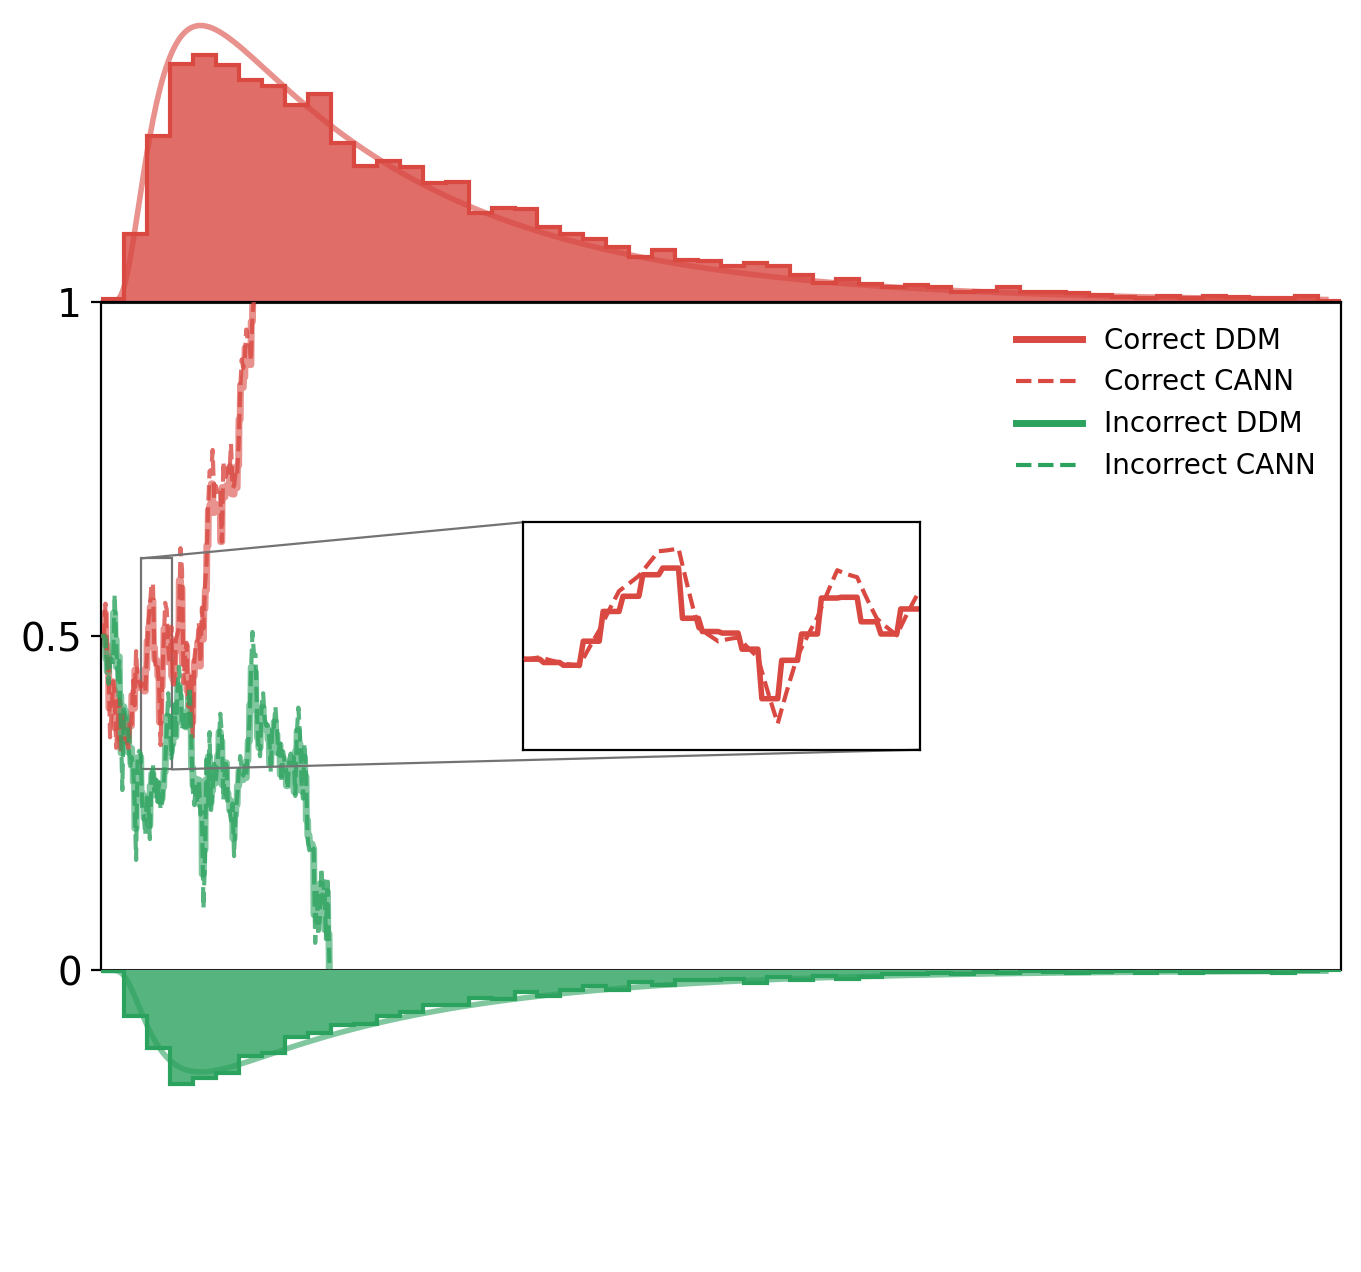

In [10]:
BIN_WIDTH_MS = 75.0
FIGSIZE = (8, 8)
GRID_HEIGHT_RATIOS = (1.6, 3.8, 1.6)
CORRECT_COLOR = "#d94841"
ERROR_COLOR = "#2ca25f"
HIST_ALPHA = 0.8
CIRCUIT_TRAJECTORY_ALPHA = 0.8
DDM_TRAJECTORY_ALPHA = 0.6
THEORY_ALPHA = 0.6
DDM_TRAJECTORY_LINEWIDTH = 2.5
CIRCUIT_TRAJECTORY_LINEWIDTH = 1.5
PROFILE_LINEWIDTH = 1.5
BOUNDARY_COLOR = "#222222"
fig, axes = plot_fig3_circuit_rt_traj(
    ddm_raw,
    ddm_condition_index,
    rt_raw,
    rt_condition_index,
    example_trials,
    circuit_replays,
)
plt.show()


## Notes

- The top histogram is a response subdensity over all trials from the selected RT source model, with the free-response DDM theoretical subdensity overlaid.
- The bottom histogram is the corresponding error-response subdensity, plotted downward with the matching theoretical curve.
- The panel is restricted to the selected condition from the merged psychometric run, currently `v=0.25, c=0.5`.
- The middle panel shows one median-RT correct trial and one median-RT incorrect trial reconstructed from the saved DDM condition seed.
- The notebook can use either raw per-model bundles or a merged-only top-level Figure 3 bundle.
- No figure file is written automatically in this notebook.
